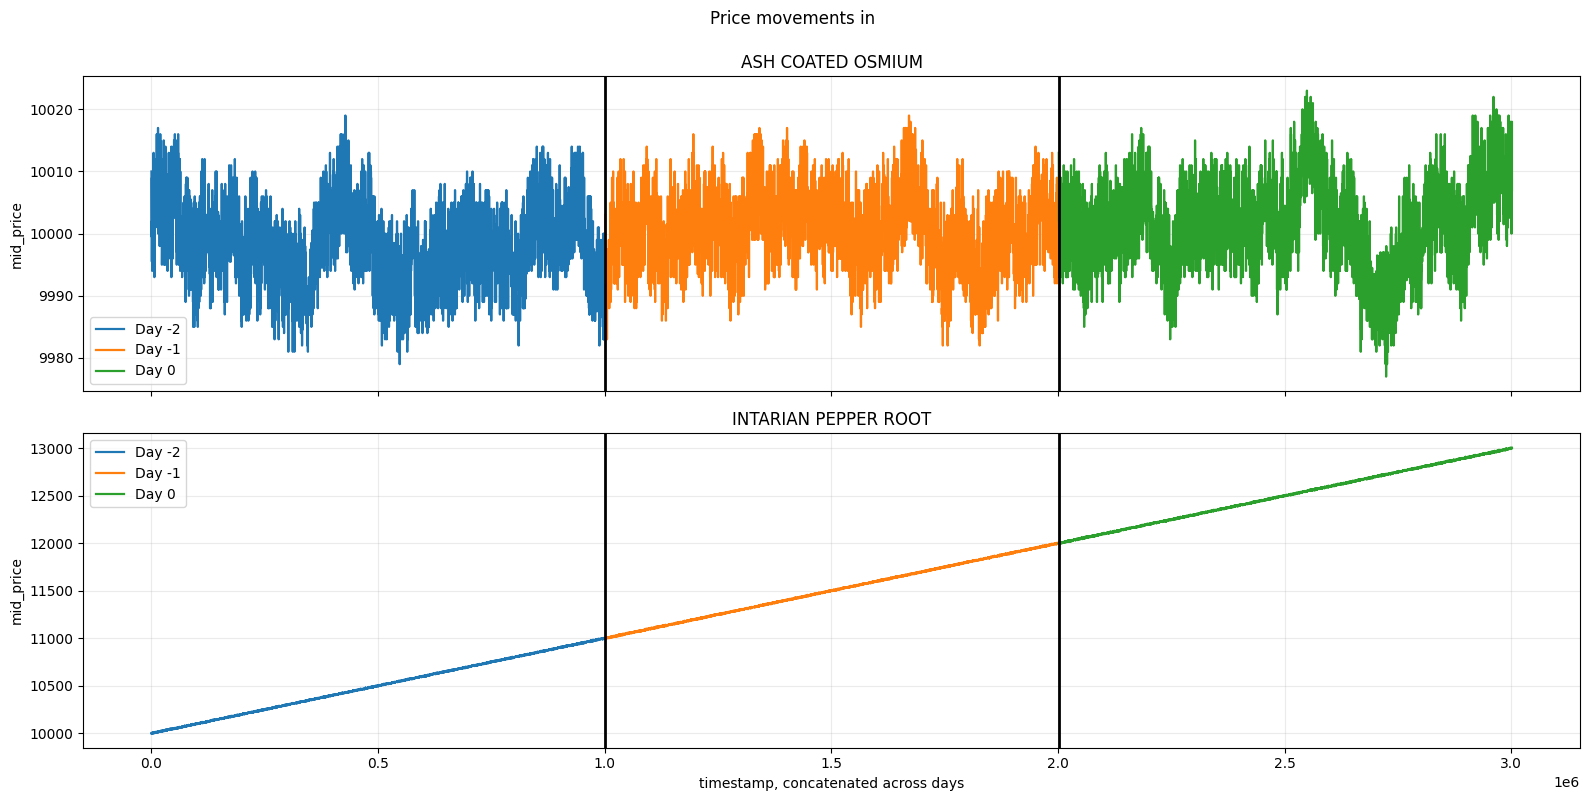

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 1
ROUND_FOLDER = Path(".")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products = sorted(plot_prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = plot_prices[plot_prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

LEVELS = (1, 2, 3)


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    notebook_dir = Path.cwd()
    for root in (notebook_dir, notebook_dir.parent):
        candidate = root / path
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find data file: {path}")


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


In [3]:
# Distribution of raw alt_mid_price changes from one tick to the next + autocorrelation.
asset = "ASH_COATED_OSMIUM"
prices_csv = "prices_round_1_day_-1.csv"

sub = load_prices(prices_csv)
sub = (
    sub[sub["product"] == asset]
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
    .reset_index(drop=True)
)

# Drop the very first tick before constructing alt_mid_price-derived diagnostics.
sub = sub.iloc[1:].reset_index(drop=True)


def reconstruct_side_levels(frame: pd.DataFrame, side: str) -> pd.DataFrame:
    value_cols = [
        col
        for col in [f"{side}_price_1", f"{side}_price_2", f"{side}_price_3"]
        if col in frame.columns
    ]

    far_values: list[float | None] = []
    mid_values: list[float | None] = []
    far_state: float | None = None
    mid_state: float | None = None

    for _, row in frame.iterrows():
        values = []
        for col in value_cols:
            value = pd.to_numeric(row[col], errors="coerce")
            if pd.notna(value) and value > 0:
                values.append(float(value))

        values.sort()

        far_value = far_state
        mid_value = mid_state

        if values:
            pair_found = False

            if side == "ask" and len(values) >= 2:
                candidate_mid = values[-2]
                candidate_far = values[-1]
                if candidate_far - candidate_mid <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True
            elif side == "bid" and len(values) >= 2:
                candidate_far = values[0]
                candidate_mid = values[1]
                if candidate_mid - candidate_far <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True

            if not pair_found:
                candidate = values[-1] if side == "ask" else values[0]

                if far_state is None or mid_state is None:
                    far_value = candidate
                    mid_value = candidate
                elif abs(candidate - far_state) <= 1:
                    far_value = candidate
                elif abs(candidate - mid_state) <= 1:
                    mid_value = candidate

        far_state = far_value
        mid_state = mid_value
        far_values.append(far_value)
        mid_values.append(mid_value)

    return pd.DataFrame({f"far_{side}": far_values, f"mid_{side}": mid_values})


bid_levels = reconstruct_side_levels(sub, "bid")
ask_levels = reconstruct_side_levels(sub, "ask")
sub = pd.concat([sub, bid_levels, ask_levels], axis=1)
sub["alt_mid_price"] = sub[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)

raw_change = sub["alt_mid_price"].diff().dropna()



In [4]:
from itertools import product
import warnings

import pandas as pd
from statsmodels.tsa.arima.model import ARIMA


def build_alt_mid_series(file_path: str, asset_name: str, drop_first_row: bool = True) -> pd.Series:
    """Load one file/asset and return the alt_mid_price series."""
    df = load_prices(file_path)
    sub = (
        df[df["product"] == asset_name.upper()]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError(f"No rows found for asset '{asset_name}' in '{file_path}'")

    if drop_first_row and len(sub) > 1:
        sub = sub.iloc[1:].reset_index(drop=True)

    bid_levels = reconstruct_side_levels(sub, "bid")
    ask_levels = reconstruct_side_levels(sub, "ask")
    sub = pd.concat([sub, bid_levels, ask_levels], axis=1)
    sub["alt_mid_price"] = sub[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)

    series = sub["alt_mid_price"].dropna().astype(float)
    if series.empty:
        raise ValueError(f"alt_mid_price is empty for asset '{asset_name}' in '{file_path}'")

    return series


def arima_grid_search_alt_mid(
    file_path: str,
    asset_name: str,
    p_values=range(0, 5),
    d_values=(0, 1, 2),
    q_values=range(0, 5),
) -> pd.DataFrame:
    """Fit ARIMA(p,d,q) candidates on alt_mid_price and return metrics table."""
    y = build_alt_mid_series(file_path=file_path, asset_name=asset_name)

    results = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for p, d, q in product(p_values, d_values, q_values):
            order = (p, d, q)
            try:
                model = ARIMA(y, order=order)
                fitted = model.fit()
                results.append(
                    {
                        "file": str(file_path),
                        "asset": asset_name.upper(),
                        "order": order,
                        "p": p,
                        "d": d,
                        "q": q,
                        "aic": float(fitted.aic),
                        "bic": float(fitted.bic),
                        "nobs": int(fitted.nobs),
                    }
                )
            except Exception as exc:
                results.append(
                    {
                        "file": str(file_path),
                        "asset": asset_name.upper(),
                        "order": order,
                        "p": p,
                        "d": d,
                        "q": q,
                        "aic": float("inf"),
                        "bic": float("inf"),
                        "nobs": len(y),
                        "error": str(exc),
                    }
                )

    out = pd.DataFrame(results)
    return out.sort_values(["aic", "bic"], ascending=True).reset_index(drop=True)


def evaluate_arima_for_files_assets(
    file_paths,
    asset_names,
    p_values=range(0, 5),
    d_values=(0, 1, 2),
    q_values=range(0, 5),
    top_n: int = 10,
):
    """
    Run ARIMA grid search for each (file, asset) pair.

    Parameters:
        file_paths: str or list[str]
        asset_names: str or list[str]
    """
    if isinstance(file_paths, (str, Path)):
        file_paths = [str(file_paths)]
    if isinstance(asset_names, str):
        asset_names = [asset_names]

    all_tables = []
    for file_path in file_paths:
        for asset_name in asset_names:
            table = arima_grid_search_alt_mid(
                file_path=file_path,
                asset_name=asset_name,
                p_values=p_values,
                d_values=d_values,
                q_values=q_values,
            )
            all_tables.append(table)

            print(f"\nTop {top_n} by AIC for {asset_name.upper()} in {file_path}")
            print(table[["order", "aic", "bic"]].head(top_n).to_string(index=False))

    combined = pd.concat(all_tables, ignore_index=True)
    combined_best = (
        combined.sort_values(["file", "asset", "aic", "bic"])
        .groupby(["file", "asset"], as_index=False)
        .first()
        .sort_values(["aic", "bic"])
        .reset_index(drop=True)
    )

    return combined, combined_best


# Example usage
combined_results, best_models = evaluate_arima_for_files_assets(
    file_paths=[
        "prices_round_1_day_-2.csv",
        "prices_round_1_day_-1.csv",
        "prices_round_1_day_0.csv",
    ],
    asset_names=["ASH_COATED_OSMIUM"],
    p_values=range(0, 4),
    d_values=(0, 1, 2),
    q_values=range(0, 4),
    top_n=8,
)

best_models[["file", "asset", "order", "aic", "bic"]]


Top 8 by AIC for ASH_COATED_OSMIUM in prices_round_1_day_-2.csv
    order         aic         bic
(1, 0, 1) 5791.066087 5819.907048
(2, 0, 0) 5791.227835 5820.068797
(2, 0, 1) 5792.771470 5828.822672
(1, 0, 2) 5792.787349 5828.838550
(3, 0, 0) 5792.789931 5828.841133
(0, 1, 1) 5792.915112 5807.335392
(1, 1, 0) 5793.121397 5807.541677
(1, 1, 1) 5794.449091 5816.079512

Top 8 by AIC for ASH_COATED_OSMIUM in prices_round_1_day_-1.csv
    order         aic         bic
(1, 0, 2) 6216.642655 6252.693857
(3, 0, 0) 6216.772807 6252.824009
(2, 0, 1) 6218.046768 6254.097969
(2, 0, 2) 6218.347277 6261.608719
(1, 0, 1) 6218.497616 6247.338577
(1, 0, 3) 6218.567718 6261.829160
(2, 0, 0) 6218.967581 6247.808543
(2, 1, 2) 6220.332913 6256.383615

Top 8 by AIC for ASH_COATED_OSMIUM in prices_round_1_day_0.csv
    order         aic         bic
(1, 0, 1) 5988.547329 6017.388290
(2, 0, 0) 5988.581201 6017.422162
(0, 1, 1) 5988.615411 6003.035692
(1, 1, 0) 5988.659993 6003.080273
(1, 0, 0) 5989.156829 60

,file,asset,order,aic,bic
0,prices_round_1_day_-2.csv,ASH_COATED_OSMIUM,"(1, 0, 1)",5791.066087,5819.907048
1,prices_round_1_day_0.csv,ASH_COATED_OSMIUM,"(1, 0, 1)",5988.547329,6017.388290
2,prices_round_1_day_-1.csv,ASH_COATED_OSMIUM,"(1, 0, 2)",6216.642655,6252.693857


In [5]:
import ast
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox


def _parse_order(order_value):
    if isinstance(order_value, tuple):
        return order_value
    if isinstance(order_value, str):
        parsed = ast.literal_eval(order_value)
        if isinstance(parsed, tuple) and len(parsed) == 3:
            return parsed
    raise ValueError(f"Could not parse ARIMA order from value: {order_value}")


def select_validation_candidates(
    all_results_df: pd.DataFrame,
    per_file_top_n: int = 5,
    require_each_d: bool = True,
) -> pd.DataFrame:
    """Select multiple ARIMA candidates per (file, asset), including at least one per d."""
    candidates = []

    for (file_path, asset_name), grp in all_results_df.groupby(["file", "asset"]):
        valid = grp[np.isfinite(grp["aic"]) & np.isfinite(grp["bic"])].copy()
        valid = valid.sort_values(["aic", "bic"]).reset_index(drop=True)
        if valid.empty:
            continue

        chosen = valid.head(per_file_top_n).copy()

        if require_each_d:
            for d_val in sorted(valid["d"].dropna().unique()):
                if d_val not in set(chosen["d"]):
                    best_for_d = valid[valid["d"] == d_val].head(1)
                    chosen = pd.concat([chosen, best_for_d], ignore_index=True)

        chosen = chosen.drop_duplicates(subset=["file", "asset", "order"]).reset_index(drop=True)
        candidates.append(chosen)

    if not candidates:
        raise ValueError("No valid ARIMA candidates found to validate.")

    out = pd.concat(candidates, ignore_index=True)
    return out.sort_values(["file", "asset", "aic", "bic"]).reset_index(drop=True)


def validate_candidate_models(
    candidate_models_df: pd.DataFrame,
    holdout_frac: float = 0.2,
    lb_lag: int = 10,
) -> pd.DataFrame:
    rows = []

    for _, r in candidate_models_df.iterrows():
        file_path = r["file"]
        asset_name = r["asset"]
        order = _parse_order(r["order"])

        y = build_alt_mid_series(file_path=file_path, asset_name=asset_name)
        n = len(y)
        split_idx = max(20, int(n * (1 - holdout_frac)))
        split_idx = min(split_idx, n - 1)

        train = y.iloc[:split_idx]
        test = y.iloc[split_idx:]

        fitted_full = ARIMA(y, order=order).fit()
        resid = pd.Series(fitted_full.resid).dropna()
        lb = acorr_ljungbox(resid, lags=[lb_lag], return_df=True)
        lb_pvalue = float(lb["lb_pvalue"].iloc[0])

        fitted_train = ARIMA(train, order=order).fit()
        preds = fitted_train.forecast(steps=len(test))

        mae = float((test - preds).abs().mean())
        rmse = float(np.sqrt(((test - preds) ** 2).mean()))

        rows.append(
            {
                "file": file_path,
                "asset": asset_name,
                "order": order,
                "p": int(order[0]),
                "d": int(order[1]),
                "q": int(order[2]),
                "train_n": int(len(train)),
                "test_n": int(len(test)),
                "aic": float(fitted_full.aic),
                "bic": float(fitted_full.bic),
                "mae": mae,
                "rmse": rmse,
                "lb_pvalue_lag10": lb_pvalue,
                "residuals_look_white": lb_pvalue > 0.05,
            }
        )

    out = pd.DataFrame(rows)
    return out.sort_values(["file", "asset", "mae", "rmse", "aic"]).reset_index(drop=True)


candidate_models = select_validation_candidates(
    combined_results,
    per_file_top_n=5,
    require_each_d=True,
)

validation_summary = validate_candidate_models(
    candidate_models,
    holdout_frac=0.2,
    lb_lag=10,
)

print("Candidates selected per file/asset and d:")
print(candidate_models.groupby(["file", "asset", "d"]).size().rename("n_models").to_string())

validation_summary[
    [
        "file",
        "asset",
        "order",
        "d",
        "aic",
        "bic",
        "mae",
        "rmse",
        "lb_pvalue_lag10",
        "residuals_look_white",
    ]
]

C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Candidates selected per file/asset and d:
file                       asset              d
prices_round_1_day_-1.csv  ASH_COATED_OSMIUM  0    5
                                              1    1
                                              2    1
prices_round_1_day_-2.csv  ASH_COATED_OSMIUM  0    5
                                              1    1
                                              2    1
prices_round_1_day_0.csv   ASH_COATED_OSMIUM  0    3
                                              1    2
                                              2    1


,file,asset,order,d,aic,bic,mae,rmse,lb_pvalue_lag10,residuals_look_white
0,prices_round_1_day_-1.csv,ASH_COATED_OSMIUM,"(2, 0, 1)",0,6218.046768,6254.097969,2.583278,3.091870,0.011418,False
1,prices_round_1_day_-1.csv,ASH_COATED_OSMIUM,"(1, 0, 2)",0,6216.642655,6252.693857,2.583832,3.092752,0.015473,False
2,prices_round_1_day_-1.csv,ASH_COATED_OSMIUM,"(2, 0, 2)",0,6218.347277,6261.608719,2.644245,3.207043,0.015853,False
3,prices_round_1_day_-1.csv,ASH_COATED_OSMIUM,"(3, 0, 0)",0,6216.772807,6252.824009,2.730749,3.323995,0.015018,False
4,prices_round_1_day_-1.csv,ASH_COATED_OSMIUM,"(1, 0, 1)",0,6218.497616,6247.338577,2.749839,3.349760,0.004650,False
5,prices_round_1_day_-1.csv,ASH_COATED_OSMIUM,"(0, 2, 3)",2,6235.715125,6264.555286,3.854334,4.683683,0.000000,False
6,prices_round_1_day_-1.csv,ASH_COATED_OSMIUM,"(2, 1, 2)",1,6220.332913,6256.383615,4.011760,4.856924,1.000000,True
7,prices_round_1_day_-2.csv,ASH_COATED_OSMIUM,"(2, 0, 0)",0,5791.227835,5820.068797,4.766085,5.370195,0.935983,True
8,prices_round_1_day_-2.csv,ASH_COATED_OSMIUM,"(1, 0, 1)",0,5791.066087,5819.907048,4.767119,5.371381,0.945209,True
9,prices_round_1_day_-2.csv,ASH_COATED_OSMIUM,"(3, 0, 0)",0,5792.789931,5828.841133,4.770343,5.375078,0.957628,True


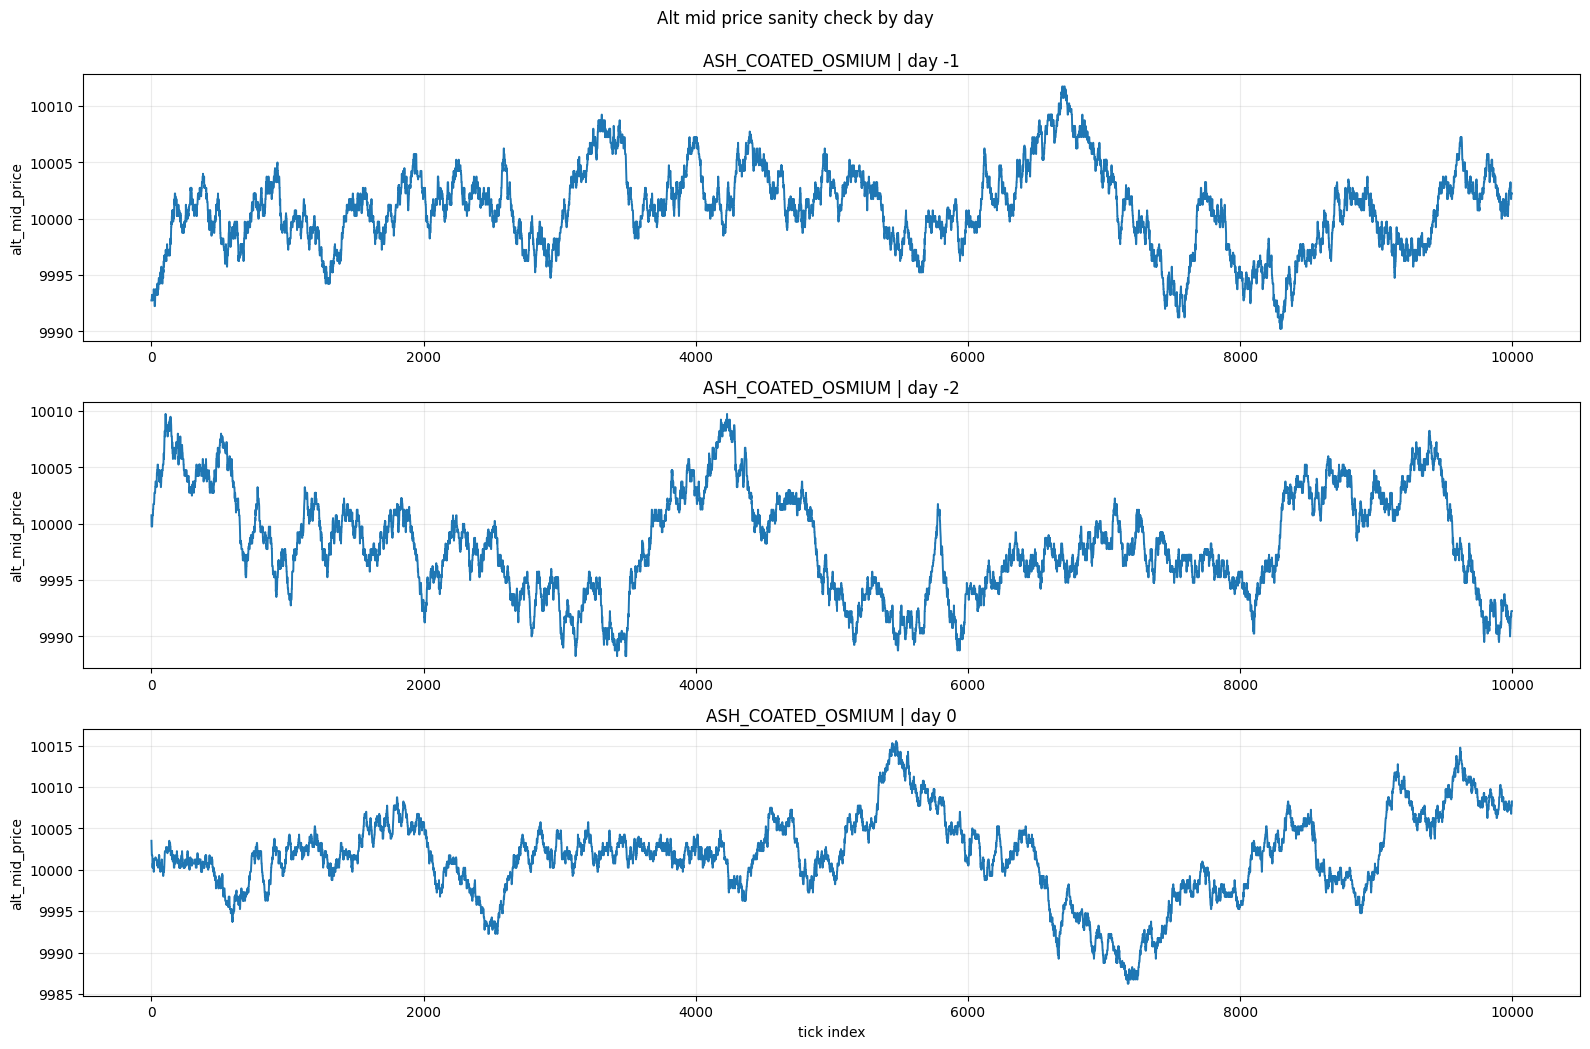

In [6]:
# Sanity check: plot alt_mid_price separately for each day for one asset.
asset_for_plot = "ASH_COATED_OSMIUM"
files_for_plot = sorted(PRICE_FILES)

if not files_for_plot:
    raise ValueError("No files found in PRICE_FILES to plot.")

fig, axes = plt.subplots(
    nrows=len(files_for_plot),
    ncols=1,
    figsize=(16, max(4, 3.5 * len(files_for_plot))),
    sharex=False,
)

if len(files_for_plot) == 1:
    axes = [axes]

for ax, fp in zip(axes, files_for_plot):
    day_match = DAY_RE.search(fp.name)
    day_label = day_match.group(1) if day_match else "?"

    alt_series = build_alt_mid_series(str(fp), asset_for_plot)
    ax.plot(alt_series.values, linewidth=1.4)
    ax.set_title(f"{asset_for_plot} | day {day_label}")
    ax.set_ylabel("alt_mid_price")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("tick index")
fig.suptitle("Alt mid price sanity check by day", y=0.995)
fig.tight_layout()
plt.show()